# Task 5: Evaluation and Interpretability

The model is already trained. Here we check how it does on the held-out test set, decide where to set the decision threshold for a retention campaign, and turn the strongest churn drivers into actions a CRM team can actually run.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve, precision_recall_curve
)
from sklearn.inspection import permutation_importance
import joblib

sns.set_style('whitegrid')

In [2]:
BASE_DIR = Path.cwd()
model_path = BASE_DIR / 'best_churn_model.joblib'
test_path = BASE_DIR / 'test_split.csv'

if not model_path.exists() or not test_path.exists():
    raise FileNotFoundError('Please run Notebook 4 first to generate model and test split artifacts.')

model = joblib.load(model_path)
test_df = pd.read_csv(test_path)

y_test = test_df['churn_label'].astype(int)
X_test = test_df.drop(columns=['churn_label'])

print('Loaded test rows:', len(test_df))

Loaded test rows: 640


## Metrics on the held-out test set

For a retention campaign the expensive mistake is missing a churner: if we don't reach them, they leave. That makes recall the metric to prioritise, since it tells us how many of the real churners we actually flag.

Precision still matters because every flagged customer costs something to treat (a discount, an email, an agent's time), so we don't want to blanket everyone. F1 balances the two, and ROC-AUC says how well the model ranks risk regardless of where the cut-off sits. We report all four but lean on recall when picking the operating point.


In [3]:
# Start at the default 0.5 cut-off and score the test set.
threshold = 0.5
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= threshold).astype(int)

metrics = {
    'precision': precision_score(y_test, y_pred, zero_division=0),
    'recall': recall_score(y_test, y_pred, zero_division=0),
    'f1_score': f1_score(y_test, y_pred, zero_division=0),
    'roc_auc': roc_auc_score(y_test, y_prob)
}
display(pd.Series(metrics, name='value').to_frame())

print(classification_report(y_test, y_pred, digits=4))


,value
precision,0.538217
recall,0.728448
f1_score,0.619048
roc_auc,0.756518


              precision    recall  f1-score   support

           0     0.8067    0.6446    0.7166       408
           1     0.5382    0.7284    0.6190       232

    accuracy                         0.6750       640
   macro avg     0.6725    0.6865    0.6678       640
weighted avg     0.7094    0.6750    0.6813       640



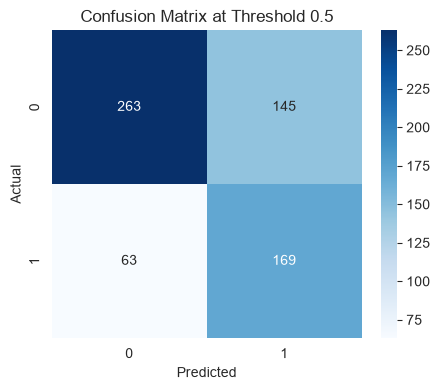

In [4]:
# Where it gets things right vs wrong at 0.5.
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix at Threshold 0.5')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


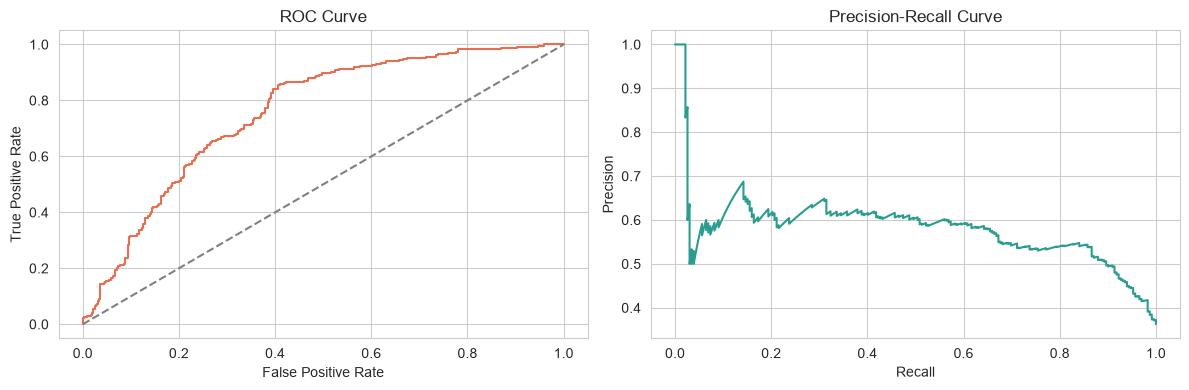

In [5]:
# How the model behaves across every threshold, not just 0.5.
fpr, tpr, _ = roc_curve(y_test, y_prob)
prec, rec, th = precision_recall_curve(y_test, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(fpr, tpr, color='#e76f51')
axes[0].plot([0, 1], [0, 1], '--', color='gray')
axes[0].set_title('ROC Curve')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')

axes[1].plot(rec, prec, color='#2a9d8f')
axes[1].set_title('Precision-Recall Curve')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')

plt.tight_layout()
plt.show()


## Choosing a decision threshold

0.5 is just a default. Since the priority is catching churners, we sweep the threshold and take the one that gives the highest recall while keeping precision above a floor we can live with (0.25 here).

**Why accept a low precision floor?** In a retention campaign the two errors are not equal. Missing a churner means losing a customer and their future revenue; a false alarm just means a relatively cheap touch (an email or a small discount) sent to someone who would have stayed anyway. When a retained customer is worth far more than the cost of one outreach, it pays to over-cast the net: we accept roughly two to three contacts per genuine churner in exchange for catching almost all of them. If outreach were expensive (e.g. an agent call), we would raise the precision floor and move the threshold up.


In [6]:
# Sweep thresholds from 0.1 to 0.9 and record what each does to precision/recall/F1.
candidate_thresholds = np.linspace(0.1, 0.9, 81)
rows = []

for t in candidate_thresholds:
    pred_t = (y_prob >= t).astype(int)
    rows.append({
        'threshold': t,
        'precision': precision_score(y_test, pred_t, zero_division=0),
        'recall': recall_score(y_test, pred_t, zero_division=0),
        'f1': f1_score(y_test, pred_t, zero_division=0)
    })

th_df = pd.DataFrame(rows)

# Keep the precision floor we're willing to live with, then grab the most aggressive
# (highest recall) threshold that still clears it.
precision_floor = 0.25
eligible = th_df[th_df['precision'] >= precision_floor]

if len(eligible) == 0:
    best_row = th_df.sort_values('f1', ascending=False).iloc[0]
    selection_rule = 'No threshold met precision floor; selected by best F1.'
else:
    best_row = eligible.sort_values(['recall', 'f1'], ascending=[False, False]).iloc[0]
    selection_rule = 'Selected highest recall among thresholds meeting precision floor.'

display(best_row.to_frame('value'))
print(selection_rule)


,value
threshold,0.140000
precision,0.383973
recall,0.991379
f1,0.553550


Selected highest recall among thresholds meeting precision floor.


,feature,importance_mean,importance_std
17,active_months,0.021244,0.007230
15,recency_to_tenure_ratio,0.009385,0.005564
4,unique_products,0.008872,0.005181
8,recency_days,0.005894,0.004317
16,distinct_active_days,0.004599,0.004076
26,return_invoice_ratio,0.003478,0.001263
9,tenure_days,0.003360,0.003319
1,purchase_lines,0.003246,0.003309
18,avg_gap_days,0.002932,0.002009
19,median_gap_days,0.002526,0.001933


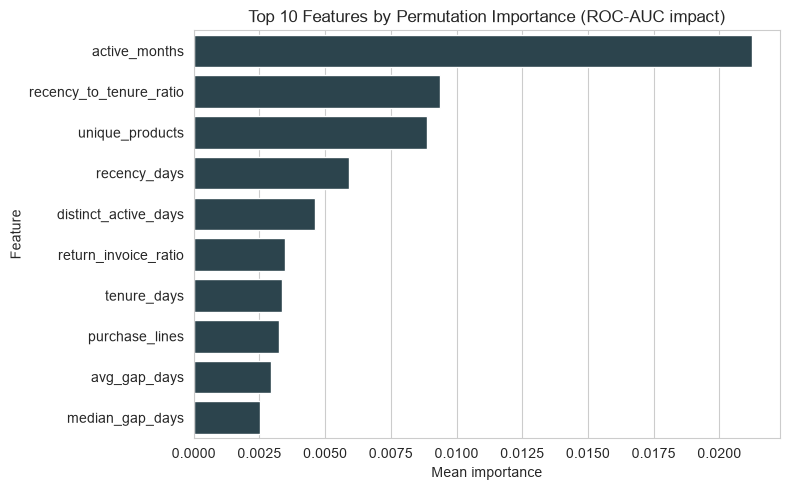

In [7]:
# Which features actually matter? Shuffle each one and see how much ROC-AUC drops.
perm = permutation_importance(
    model, X_test, y_test, n_repeats=10, random_state=42, scoring='roc_auc', n_jobs=-1
)

importance_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': perm['importances_mean'],
    'importance_std': perm['importances_std']
}).sort_values('importance_mean', ascending=False)

top_features = importance_df.head(10).copy()
display(top_features)

plt.figure(figsize=(8, 5))
sns.barplot(data=top_features, x='importance_mean', y='feature', color='#264653')
plt.title('Top 10 Features by Permutation Importance (ROC-AUC impact)')
plt.xlabel('Mean importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


## From drivers to retention actions

Importance scores are only useful if we act on them. Below we take the drivers the model actually leaned on, note which direction pushes risk up (from the sign of each feature's correlation with churn, so it holds whatever model wins), and pair each with a concrete retention play.

In [8]:
# Tie the recommendations to the drivers the model actually used. Permutation
# importance gives the magnitude; the sign of each feature's correlation with the
# label gives the direction. Correlation is model-agnostic, so this still reads
# cleanly whether the tuned model is linear (logistic regression) or tree-based.
corr_with_churn = (
    pd.concat([X_test.reset_index(drop=True),
               y_test.reset_index(drop=True).rename('churn')], axis=1)
    .corr(numeric_only=True)['churn']
)

action_map = {
    'active_months': 'Few active months means the buying habit never took hold. Push an early second/third order with onboarding nudges and replenishment reminders.',
    'recency_to_tenure_ratio': 'Customers dormant for most of their lifetime are drifting off. Reach out with win-back contact before the gap widens.',
    'recency_days': 'A long silence is the clearest warning sign. Fire a time-bound win-back offer once recency passes the usual re-purchase gap.',
    'unique_products': 'A narrow product range keeps customers loosely attached. Cross-sell adjacent categories to deepen the basket.',
    'distinct_active_days': 'Few shopping days means weak engagement. Use lifecycle email/app nudges to build a routine.',
    'frequency_orders': 'Low early order counts predict drop-off. Reward the next order with loyalty points or a threshold discount.',
    'avg_gap_days': 'Long gaps between orders point to missed replenishment. Time reminders to the category cycle.',
    'median_gap_days': 'Long gaps between orders point to missed replenishment. Time reminders to the category cycle.',
    'tenure_days': 'Short-tenure customers churn faster. Invest in a strong first-weeks onboarding journey.',
    'return_invoice_ratio': 'Counter-intuitively, customers who never return anything are the ones who quietly lapse - a return here marks an active, engaged buyer. Read very low overall interaction as a churn signal, not a good sign.',
    'purchase_lines': 'Thin purchase activity signals low commitment. Encourage larger, more varied baskets with recommendations.',
}

# Take the strongest drivers and describe the risky end of each.
top_drivers = importance_df.head(6)['feature'].tolist()
rows = []
for f in top_drivers:
    risky_end = 'higher' if corr_with_churn.get(f, 0.0) > 0 else 'lower'
    rows.append({
        'driver': f,
        'risk_signal': f'{risky_end} {f} -> more likely to churn',
        'recommended_action': action_map.get(
            f, 'Flag for CRM review and design a targeted treatment around this driver.'
        )
    })

rec_df = pd.DataFrame(rows)
display(rec_df)

,driver,risk_signal,recommended_action
0,active_months,lower active_months -> more likely to churn,Few active months means the buying habit never...
1,recency_to_tenure_ratio,higher recency_to_tenure_ratio -> more likely ...,Customers dormant for most of their lifetime a...
2,unique_products,lower unique_products -> more likely to churn,A narrow product range keeps customers loosely...
3,recency_days,higher recency_days -> more likely to churn,A long silence is the clearest warning sign. F...
4,distinct_active_days,lower distinct_active_days -> more likely to c...,Few shopping days means weak engagement. Use l...
5,return_invoice_ratio,lower return_invoice_ratio -> more likely to c...,"Counter-intuitively, customers who never retur..."


In [9]:
# Write out everything the slide deck will draw on.
output_metrics = BASE_DIR / 'final_test_metrics.json'
with open(output_metrics, 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2)

th_df.to_csv(BASE_DIR / 'threshold_sensitivity.csv', index=False)
importance_df.to_csv(BASE_DIR / 'feature_importance_permutation.csv', index=False)
rec_df.to_csv(BASE_DIR / 'retention_recommendations.csv', index=False)

print('Saved final evaluation artifacts and business recommendation tables.')


Saved final evaluation artifacts and business recommendation tables.
